# [Lab 5-2] Variational Autoencoder (VAE)를 활용한 잠재 공간 매니폴드 생성 실습

본 실습에서는 단순한 압축/복원을 넘어 **새로운 데이터를 생성(Generation)**할 수 있는 대표적인 심층 확률적 생성 모델인 **Variational Autoencoder (VAE)**의 이론적 원리와 아키텍처를 배우고 직접 구현합니다.

---

### 💡 Autoencoder vs Variational Autoencoder (VAE)
| 구분 | 일반 Autoencoder (AE) | Variational Autoencoder (VAE) |
|---|---|---|
| **잠재 공간 (Latent Space)** | 고정된 결정론적 점 (Deterministic Vector) | **확률 분포 (평균 $\mu$, 분산 $\sigma^2$)** |
| **잠재 공간 분포** | 불연속적이고 빈 공간(Hole) 존재 | **표준 정규분포 $\mathcal{N}(0, I)$로 정렬 및 연속성 확보** |
| **주요 목적** | 차원 축소, 압축, 노이즈 제거, 이상 탐지 | **새로운 데이터 생성 (Generative Modeling)**, 매니폴드 보간 |

---

### 📐 VAE의 3대 핵심 메커니즘
1. **확률적 인코더 (Probabilistic Encoder)**:
   - 입력 $x$로부터 하나의 잠재 벡터가 아닌, 잠재 변수의 **평균 벡터 $\mu$**와 **로그 분산 벡터 $\log(\sigma^2)$**를 추정합니다.
2. **재매개변수화 트릭 (Reparameterization Trick)**:
   - 확률적 샘플링($z \sim \mathcal{N}(\mu, \sigma^2)$) 노드는 미분이 불가능하여 오차 역전파(Backpropagation)가 불가능합니다.
   - 외부 표준 정규 난수 $\epsilon \sim \mathcal{N}(0, I)$를 도입하여 **$z = \mu + \sigma \odot \epsilon$** 형태로 분리함으로써 역전파가 가능하도록 만듭니다.
3. **ELBO 손실 함수 (Evidence Lower Bound)**:
   $$\text{Total Loss} = \text{Reconstruction Loss} + D_{KL}(q(z|x) \,||\, p(z))$$
   - **재구성 손실 (Reconstruction Loss)**: 원본 $x$를 얼마나 정밀하게 복원했는가 (Binary Cross-Entropy)
   - **KL 발산 손실 (KL Divergence Loss)**: 잠재 공간의 분포가 표준 정규분포 $\mathcal{N}(0, I)$와 얼마나 유사하게 정렬되었는가

In [1]:
# 라이브러리 임포트 및 시각화 설정
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# 한글 폰트 및 마이너스 부호 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print(f"TensorFlow 버전: {tf.__version__}")

I0000 00:00:1790677151.105934    1675 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790677151.106499    1675 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790677151.162363    1675 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790677152.970239    1675 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

TensorFlow 버전: 2.21.0


## 1. 데이터 준비 (MNIST)

손글씨 숫자 이미지(MNIST)를 로드하고, 픽셀값을 $[0, 1]$ 범위로 정규화합니다.
합성곱 신경망 처리를 위해 `(28, 28, 1)` 크기의 4차원 텐서로 변환합니다.

In [2]:
# MNIST 데이터셋 로드
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 0~1 정규화 및 차원 확장
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print(f"훈련 데이터 형태: {x_train.shape}")
print(f"테스트 데이터 형태: {x_test.shape}")

훈련 데이터 형태: (60000, 28, 28, 1)
테스트 데이터 형태: (10000, 28, 28, 1)


## 2. VAE 아키텍처 설계

### 2.1 Reparameterization Layer (재매개변수화 트릭 계층)
평균($\mu$)과 로그 분산($\log \sigma^2$)을 입력받아 다음과 같이 잠재 벡터 $z$를 샘플링합니다:
$$z = \mu + e^{0.5 \cdot \log(\sigma^2)} \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

In [3]:
class Sampling(layers.Layer):
    # Reparameterization Trick을 구현하는 커스텀 레이어
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        # 표준 정규분포에서 입실론(epsilon) 샘플링
        epsilon = tf.random.normal(shape=(batch, dim))
        # z = mu + sigma * epsilon (sigma = exp(0.5 * log_var))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

### 2.2 인코더(Encoder)와 디코더(Decoder) 정의
2차원 평면에서의 직관적인 시각화를 위해 잠재 공간의 차원 수(`latent_dim`)를 **2**로 설정합니다.

In [4]:
latent_dim = 2

# [1. Encoder 정의]
encoder_inputs = layers.Input(shape=(28, 28, 1), name="encoder_input")
x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(encoder_inputs)
x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)

# 평균(mu)과 로그 분산(log_var) 출력 노드
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

# 재매개변수화 트릭을 통한 잠재 벡터 z 샘플링
z = Sampling()([z_mean, z_log_var])

encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

E0000 00:00:1790677154.523415    1675 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │        320 │ encoder_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │     50,192 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# [2. Decoder 정의]
latent_inputs = layers.Input(shape=(latent_dim,), name="decoder_input")
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
decoder_outputs = layers.Conv2D(1, 3, padding="same", activation="sigmoid")(x)

decoder = models.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

## 3. VAE 모델 클래스 및 손실 함수(ELBO) 구현

Keras `Model` 클래스를 상속받아 `train_step`에서 Reconstruction Loss와 KL Divergence Loss를 합산하여 역전파를 수행하도록 구현합니다.
- **재구성 손실 (Reconstruction Loss)**:
  $$\text{Reconstruction Loss} = \sum_{pixels} \text{Binary Cross-Entropy}(x, \hat{x})$$
- **KL 발산 손실 (KL Divergence Loss)**:
  $$D_{KL} = -\frac{1}{2} \sum \left( 1 + \log(\sigma^2) - \mu^2 - e^{\log(\sigma^2)} \right)$$

In [6]:
class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        # 손실 추적을 위한 Metric 객체들
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            # 1. 인코딩: z_mean, z_log_var, z 샘플링
            z_mean, z_log_var, z = self.encoder(data)
            # 2. 디코딩: 원본 복원
            reconstruction = self.decoder(z)
            
            # 3. 재구성 손실 (픽셀별 BCE 합의 배치 평균)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2)
                )
            )
            
            # 4. KL Divergence 손실 (정규분포와의 차이)
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )
            
            # 5. 최종 ELBO 손실
            total_loss = reconstruction_loss + kl_loss

        # 6. 역전파 및 가중치 업데이트
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        # 메트릭 업데이트
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

## 4. VAE 모델 학습 실행

In [7]:
# VAE 인스턴스 생성 및 컴파일
vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

# 모델 학습 (20 에포크)
history = vae.fit(
    x_train,
    epochs=20,
    batch_size=128,
    verbose=1
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 64s 131ms/step - kl_loss: 2.8263 - loss: 212.4866 - reconstruction_loss: 209.6603
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - kl_loss: 3.1911 - loss: 187.1297 - reconstruction_loss: 183.9387
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 58s 124ms/step - kl_loss: 4.9219 - loss: 169.1299 - reconstruction_loss: 164.2080
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 59s 125ms/step - kl_loss: 5.2892 - loss: 162.5264 - reconstruction_loss: 157.2372
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 58s 124ms/step - kl_loss: 5.4944 - loss: 159.5107 - reconstruction_loss: 154.0164
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 124ms/step - kl_loss: 5.6144 - loss: 157.8637 - reconstruction_loss: 152.2492
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 78s 117ms/step - kl_loss: 5.6968 - loss: 156.6719 - reconstruction_loss: 150.9751
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 60s 70ms/step - kl_loss: 5.7632 - loss: 155.6991 - reconstruction_loss: 149.9360
Epoch 9/20
469/469 ━━━━━━━

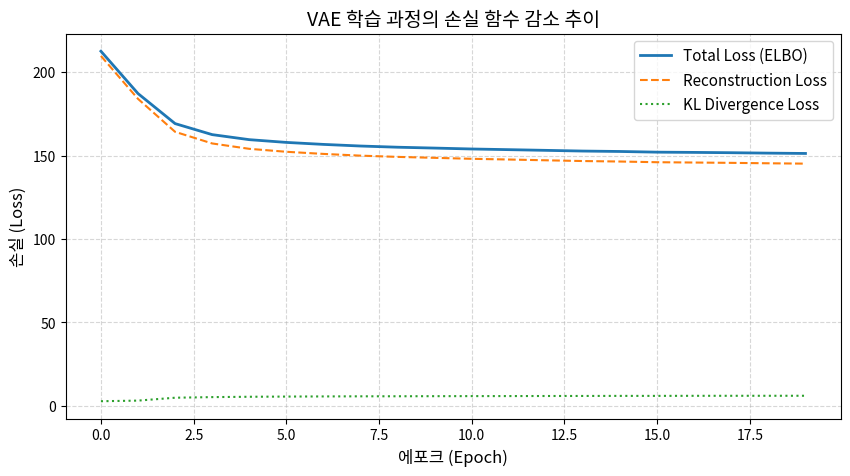

In [8]:
# 학습 손실 추이 시각화
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Total Loss (ELBO)", linewidth=2)
plt.plot(history.history["reconstruction_loss"], label="Reconstruction Loss", linestyle="--")
plt.plot(history.history["kl_loss"], label="KL Divergence Loss", linestyle=":")
plt.title("VAE 학습 과정의 손실 함수 감소 추이", fontsize=14)
plt.xlabel("에포크 (Epoch)", fontsize=12)
plt.ylabel("손실 (Loss)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 5. 2차원 잠재 공간(Latent Space) 시각화

테스트셋 이미지들을 인코더에 통과시켜 얻은 잠재 변수의 평균값 $(\mu_1, \mu_2)$을 2차원 평면에 산점도로 그립니다.
- VAE의 KL Divergence 손실 덕분에 잠재 공간의 모든 숫자들이 **원점 $(0, 0)$을 중심으로 표준 정규분포 형태로 연속적으로 매끄럽게 배치**되어 있음을 확인할 수 있습니다.

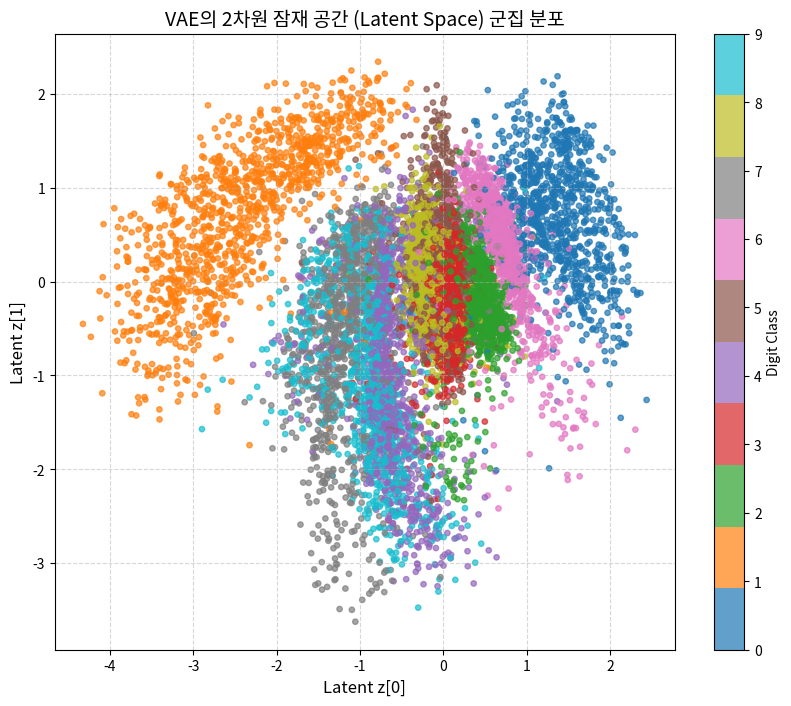

In [9]:
# 테스트 데이터 인코딩
z_mean, _, _ = vae.encoder.predict(x_test, verbose=0)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(z_mean[:, 0], z_mean[:, 1], c=y_test, cmap="tab10", alpha=0.7, s=15)
plt.colorbar(scatter, ticks=range(10), label="Digit Class")
plt.xlabel("Latent z[0]", fontsize=12)
plt.ylabel("Latent z[1]", fontsize=12)
plt.title("VAE의 2차원 잠재 공간 (Latent Space) 군집 분포", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 6. 잠재 공간 매니폴드 탐색 (2D Latent Manifold Image Generation)

2차원 잠재 평면에서 $z_1 \in [-3, 3]$과 $z_2 \in [-3, 3]$ 범위의 균등 격자 좌표를 생성하여 디코더에 입력합니다.
- 잠재 공간의 좌표가 연속적으로 이동함에 따라, **숫자 형태가 부드럽게 변형(Interpolation/Morphing)되며 새로운 손글씨가 생성되는 과정**을 한눈에 확인할 수 있습니다!

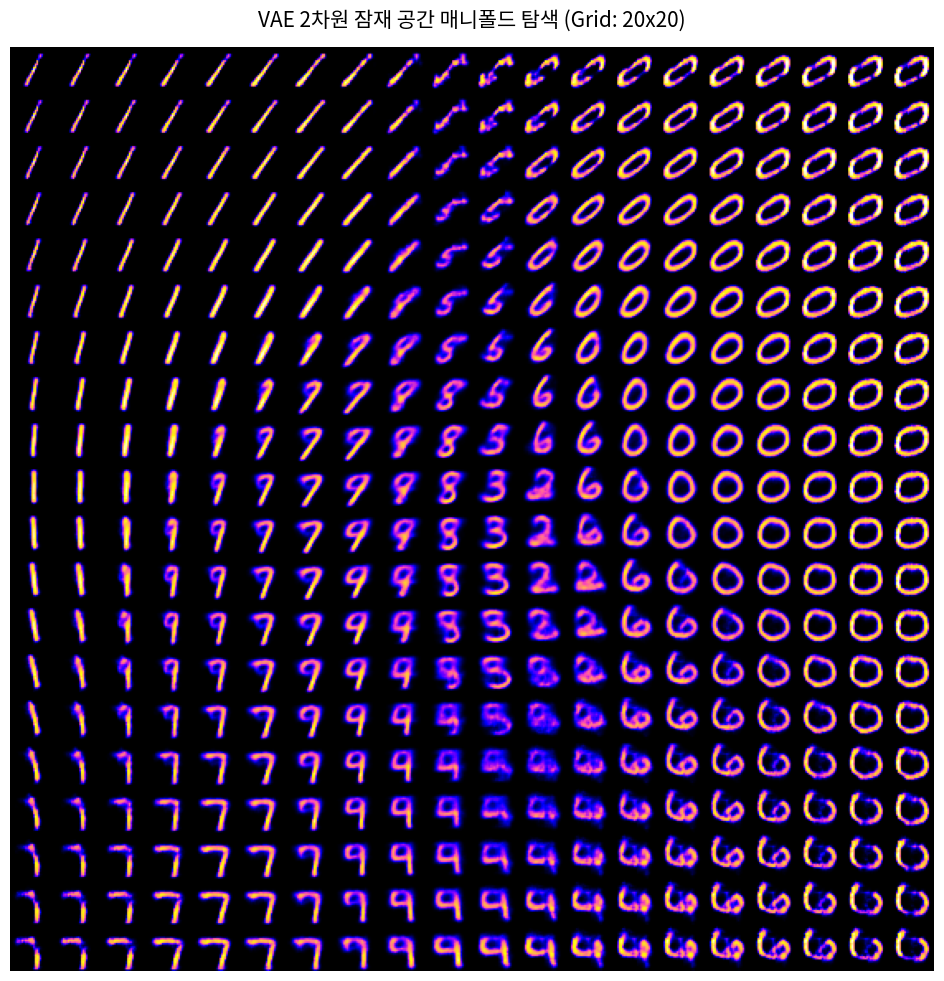

In [10]:
# 2D 잠재 공간 매니폴드 이미지 그리드 생성 함수
def plot_latent_manifold(decoder, n=20, figsize=12):
    digit_size = 28
    figure = np.zeros((digit_size * n, digit_size * n))
    
    # z1, z2를 -3부터 3까지 균등하게 분할
    grid_x = np.linspace(-3.0, 3.0, n)
    grid_y = np.linspace(-3.0, 3.0, n)[::-1]  # 위에서 아래로 정렬

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi]])
            x_decoded = decoder.predict(z_sample, verbose=0)
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[
                i * digit_size : (i + 1) * digit_size,
                j * digit_size : (j + 1) * digit_size,
            ] = digit

    plt.figure(figsize=(figsize, figsize))
    plt.imshow(figure, cmap="gnuplot2")
    plt.axis("off")
    plt.title(f"VAE 2차원 잠재 공간 매니폴드 탐색 (Grid: {n}x{n})", fontsize=15, pad=15)
    plt.show()

# 매니폴드 생성 시각화 실행
plot_latent_manifold(vae.decoder, n=20)

## 7. 원본 이미지 vs VAE 복원 이미지 비교

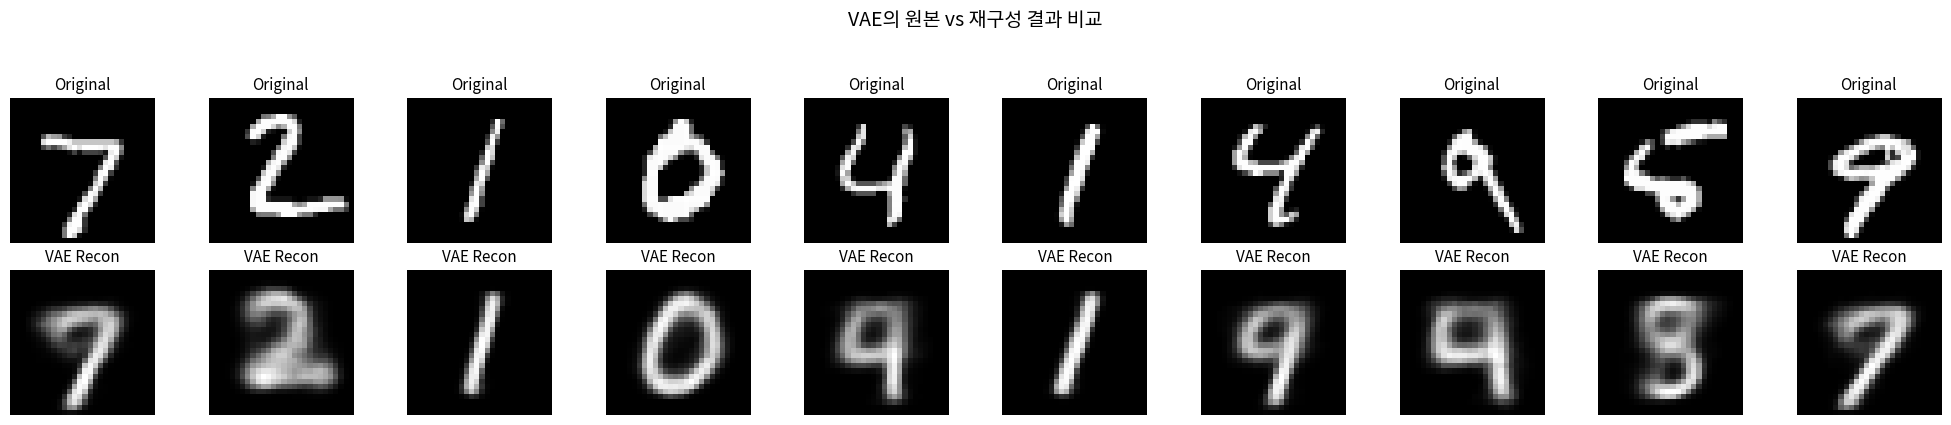

In [11]:
# 테스트 샘플 복원 확인
z_mean, _, z = vae.encoder.predict(x_test[:10], verbose=0)
reconstructed = vae.decoder.predict(z, verbose=0)

plt.figure(figsize=(20, 4))
for i in range(10):
    # 원본
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title("Original", fontsize=11)
    plt.axis("off")

    # 복원
    ax = plt.subplot(2, 10, i + 1 + 10)
    plt.imshow(reconstructed[i].reshape(28, 28), cmap="gray")
    plt.title("VAE Recon", fontsize=11)
    plt.axis("off")

plt.suptitle("VAE의 원본 vs 재구성 결과 비교", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

## 8. 실습 요약 및 핵심 정리

1. **VAE의 생성 모델링 원리**:
   - 일반 오토인코더와 달리 잠재 변수를 확률 분포($\mu, \sigma^2$)로 매핑하고, 표준 정규분포 $\mathcal{N}(0, I)$로 정규화(KL Divergence)함으로써 **비어 있는 공간 없이 연속적이고 해석 가능한 잠재 공간**을 구축합니다.
2. **Reparameterization Trick**:
   - 확률적 샘플링의 비미분성 문제를 난수 변수 $\epsilon$의 선형 결합($z = \mu + \sigma \odot \epsilon$)으로 분리하여 엔드투엔드 역전파 학습을 가능하게 한 획기적인 기법입니다.
3. **생성 매니폴드의 가치**:
   - 2차원 잠재 평면 위의 임의의 좌표 $(z_1, z_2)$를 디코더에 통과시키는 것만으로 기존 데이터에 없던 새로운 손글씨 숫자를 무한히 생성할 수 있음을 매니폴드 그리드를 통해 검증했습니다.
4. **한계점과 다음 단계**:
   - VAE는 픽셀 평균 오차 기반 복원 특성상 다소 흐릿한(Blurry) 이미지가 생성될 수 있습니다. $\to$ 이는 보다 선명한 생성을 달성하는 **GAN(Lab 5-3)** 및 **Diffusion Model(Lab 5-4)** 실습으로 이어집니다.

---
## 📝 [실습 5-2 수행 결과 정리]

> 실행 환경: TensorFlow 2.21.0 / Keras 3.15.1 (CPU). 코드는 원본 그대로 실행했습니다. 아래 수치 중 노트북 출력에 없는 값(잠재공간 통계, 생성 샘플 판정)은 학습이 끝난 모델로 따로 측정했습니다. 생성 샘플 판정에는 **별도로 학습한 MNIST CNN 분류기(테스트 정확도 98.75%)**를 썼습니다.

### 1) 학습 결과 (20 Epoch)

| 손실 | Epoch 1 | Epoch 20 | 변화 |
|:---|:---:|:---:|:---|
| Total Loss (ELBO) | 212.49 | **151.24** | ▼ 28.8% |
| Reconstruction Loss | 209.66 | **145.15** | ▼ 30.8% |
| KL Divergence | 2.83 | **6.10** | ▲ 증가 |

- 전체 손실은 **재구성 손실이 줄어든 만큼** 내려갔고, KL 손실은 오히려 2.8 → 6.1로 올랐습니다.
- 초반에는 인코더 출력이 사전분포 $\mathcal{N}(0, I)$ 근처에 머물러 KL은 작지만 복원이 나쁩니다. 학습이 진행되면서 모델이 **KL을 조금 늘리는 대신 입력 정보를 더 담는** 쪽으로 균형을 옮긴 결과입니다(재구성 ↔ 정규화 trade-off).

### 2) 잠재 공간이 정말 $\mathcal{N}(0, I)$에 가까운가? (테스트 10,000장의 $\mu$ 기준)

| 항목 | 측정값 | 해석 |
|:---|:---:|:---|
| $\mu$의 평균 $(z_0, z_1)$ | (−0.30, −0.12) | 원점 근처 |
| $\mu$의 표준편차 $(z_0, z_1)$ | (1.10, 0.96) | 표준정규의 σ=1과 거의 같음 |
| 반경 3 이내 비율 | 95.9% | 이론값 98.9%에 근접 |
| 인코더가 출력한 σ의 평균 | (0.042, 0.065) | 개별 샘플의 분포는 매우 좁음 |

- **전체 샘플의 분포(aggregate posterior)**는 KL 항 덕분에 $\mathcal{N}(0, I)$ 모양으로 빈틈없이 모였습니다. 반면 샘플 하나하나의 σ는 0.04~0.07로 작아서, 각 이미지는 거의 한 점에 대응합니다. 연속성은 개별 σ보다 전체 분포의 배치에서 나온다는 뜻입니다.

### 3) 2차원 병목의 한계: 클래스 겹침

| 숫자 | 잠재공간 중심 $(z_0, z_1)$ | 관찰 |
|:---:|:---:|:---|
| 1 | (−2.34, 0.72) | 가장 멀리 떨어져 뚜렷한 군집 |
| 0 | (1.35, 0.69) | 뚜렷한 군집 |
| 4 / 9 | (−0.62, −1.02) / (−0.85, −1.04) | **중심이 거의 겹침** |
| 3 / 5 / 8 | (0.05, −0.21) / (−0.05, 0.17) / (−0.16, 0.02) | **원점 부근에 뭉침** |

- 매니폴드 그리드(20×20)에서 **'4'는 독립된 영역으로 나타나지 않고**, 아래쪽 9 영역 옆에 9와 섞인 애매한 모양으로만 보입니다. 4와 9가 같은 자리를 쓰기 때문입니다. 복원 비교에서도 입력 4 두 장이 모두 9처럼 복원되었습니다.
- 복원 이미지를 분류기로 판정하면 **원래 숫자로 인식되는 비율이 59.6%**뿐입니다(테스트 2,000장). 784차원을 2차원으로 줄이면서 클래스를 구분하는 정보가 상당히 사라졌다는 정량적 근거입니다.

### 4) 새 데이터 생성 품질: $z \sim \mathcal{N}(0, I)$ 1,000개를 디코딩한 결과

| 지표 | VAE 생성 샘플 | 실제 MNIST (기준) |
|:---|:---:|:---:|
| 분류기 평균 확신도 | 0.827 | 0.982 |
| 확신도 0.9 이상 비율 | **51.2%** | 95.2% |
| 클래스 분포 균등도 (정규화 엔트로피, 1 = 완전 균등) | 0.918 | 0.998 |
| '4' 생성 비율 | **0.2%** | 약 10% |

- 생성은 잘 되지만, **샘플 절반가량이 분류기가 확신하지 못할 만큼 흐릿합니다.** 요약에서 말한 VAE의 "Blurry" 한계를 수치로 확인한 것입니다. 픽셀 단위 BCE 평균으로 학습하면 여러 가능성의 평균 이미지가 나오기 때문입니다.
- 사전분포에서 뽑은 샘플이 겹친 영역을 지나면 특정 클래스('4', '5')가 거의 나오지 않습니다. 잠재 차원이 작을 때 생기는 다양성 손실입니다.

### 5) 핵심 정리 및 제조 AI 시사점
1. **Reparameterization Trick**으로 샘플링 노드를 $z = \mu + \sigma \odot \epsilon$로 바꿔 끝까지 역전파할 수 있었고, KL 항이 잠재공간을 $\mathcal{N}(0, I)$로 정렬해 **임의의 좌표에서 새 이미지를 만들 수 있게** 했습니다.
2. 잠재 차원이 2일 때는 시각화하기 좋지만 클래스가 겹쳐 복원 정확도가 떨어집니다. 실무에서는 `latent_dim`을 8~32 정도로 키우고, 시각화가 필요할 때만 t-SNE/UMAP으로 투영하는 편이 적절합니다.
3. 제조 현장에서는 VAE의 연속 잠재공간을 **결함 이미지 보간·증강**에 쓰거나, ELBO(재구성 + KL)를 **이상 점수**로 쓸 수 있습니다. 다만 생성 이미지가 흐릿하므로, 선명도가 중요한 결함 증강에는 GAN/Diffusion(Lab 5-3, 5-4)이 더 적합합니다.